numerical method is an approximate  soluttion method


In [ ]:
# Newton Raphson's Numerical Method
# ALGO: an iterative method for root finding
#x2=n
#f(x)=x2-n=0
#f'(x)=2x
#x(n+1)=x(n)-f(x)/f'(x)


In [ ]:
#ask the user to enter a number

In [1]:
n=input('\n Enter the number to be square rooted')


 Enter the number to be square rooted25


In [2]:
n=float(n)

In [3]:
x=20

In [4]:
while (abs(x**2-n)>0.00001):
  x=x-((x**2-n)/(2*x))


In [5]:
print(f'square root of {n} is {x} ')

square root of 25.0 is 5.000000795866174 


## IFP Project based PDA ML Training


In [6]:
import numpy as np  ## tool for calculation(maths) numpy is a python package but it is built on c++ as the coding library and it's superfast(as c++ is the fastest language)

import pandas as pd # it is the ms excel of python tabular

import matplotlib.pyplot as plt ## for plotting, pyplot is the plotting library of python in matlab

import seaborn as sns ## statistical plotting lib in python: histogram,distribution plots

In [7]:
from scipy import *  ## scitific pythonic lib for advanced math calculation like fourier transform etc
import math

## DCA
The aim here is to understand how we can use Python to fit a known model/equation into any dataset that we think must follow this physical model

Here we already know the physics: Arps decline model

Data: Volve field

Now all we need is to find the coefficients in the known equation to make it fitting to the data in hand.
Hence it's not Machine learning but an optimization problem since we already know the underlying model

In [8]:
from scipy.optimize import curve_fit

lets go thru an example first

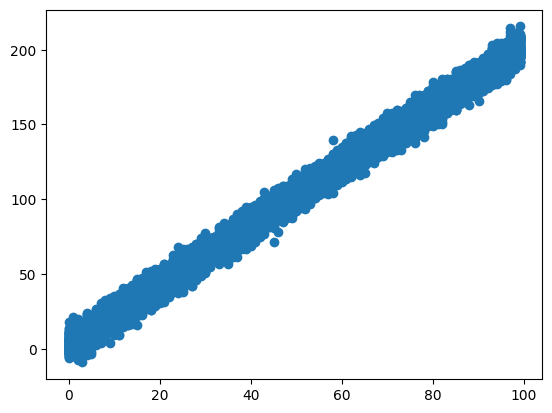

In [9]:
x=np.random.randint(0,100,10000)  # 100 data points in 0 to 100
y=2*x + 3 + np.random.randn(10000)*5   # y=mx+c+noisefor 10000 data points

plt.scatter(x,y)

#plt.plot(x,y) plpot using straight line

In [10]:
def square(num):
  return np.square(num)

square(25)

np.int64(625)

In [11]:
def linear_model(x,m,c):

  y=m*x + c
  return y


In [12]:
params=curve_fit(linear_model,x,y)

In [13]:
m,c=params[0]

In [14]:
m,c

(np.float64(2.000046705501589), np.float64(2.9772197313913544))

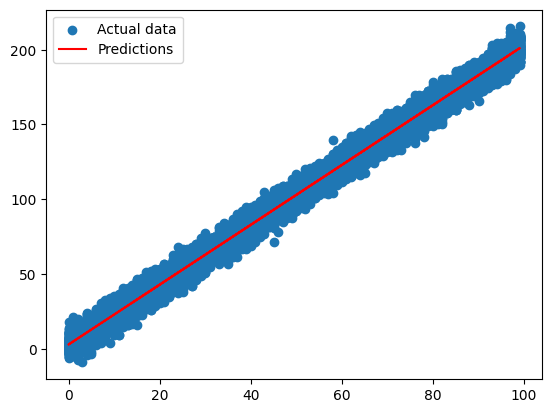

In [15]:
yp=linear_model(x,m,c)

plt.scatter(x,y, label='Actual data')
plt.plot(x,yp,color='red',label='Predictions')

plt.legend()

## TIme series data

In [16]:
dca_df=pd.read_csv('https://raw.githubusercontent.com/yohanesnuwara/pyreservoir/master/data/norne_production_rate_sample.csv',
index_col=0, parse_dates=True)

dca_df.head()

,Rate (SCF/d)
Date,
2004-04-01,2706039.0
2004-05-01,2492086.2
2004-06-02,1816846.1
2004-07-02,1920207.4
2004-07-04,1683521.4


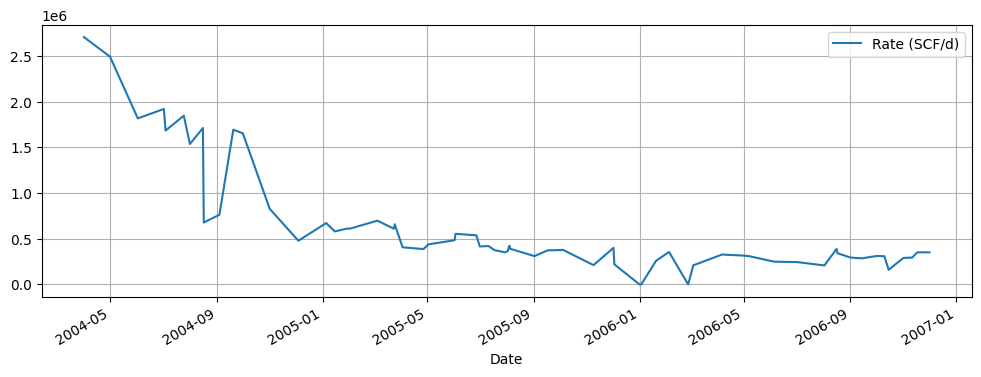

In [17]:
dca_df.plot(figsize=(12,4))
plt.grid()


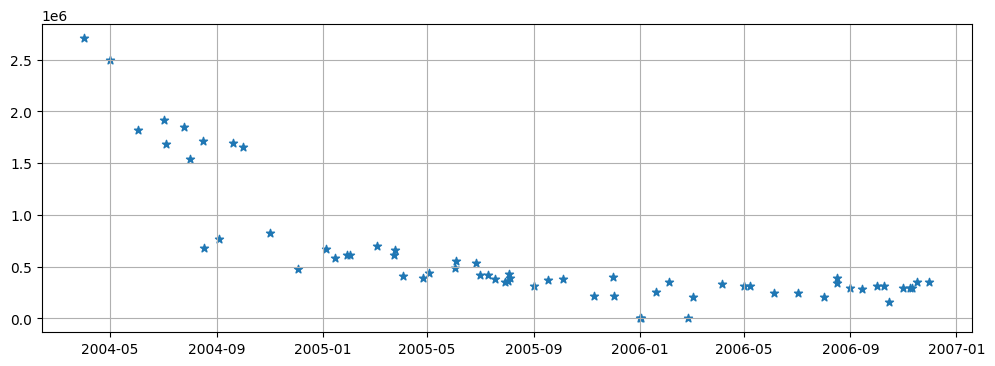

In [18]:
plt.figure(figsize=(12,4))
plt.scatter(y=dca_df['Rate (SCF/d)'],x=dca_df.index,marker='*')
plt.grid()

In [19]:
def day_maker(df):

  """pass a time series df to itand it
  will return a days column, subtracts dates and makes days.

  reuturned is days(np array)
  """
  days=[]  #list

  for d in range(len(df)):
    delta=df.index[d]-df.index[0]
    days.append(delta.days)

  days=np.array(days)
  return days

In [20]:
dca_df['days']=day_maker(dca_df)

In [21]:
dca_df.head()

,Rate (SCF/d),days
Date,,
2004-04-01,2706039.0,0
2004-05-01,2492086.2,30
2004-06-02,1816846.1,62
2004-07-02,1920207.4,92
2004-07-04,1683521.4,94


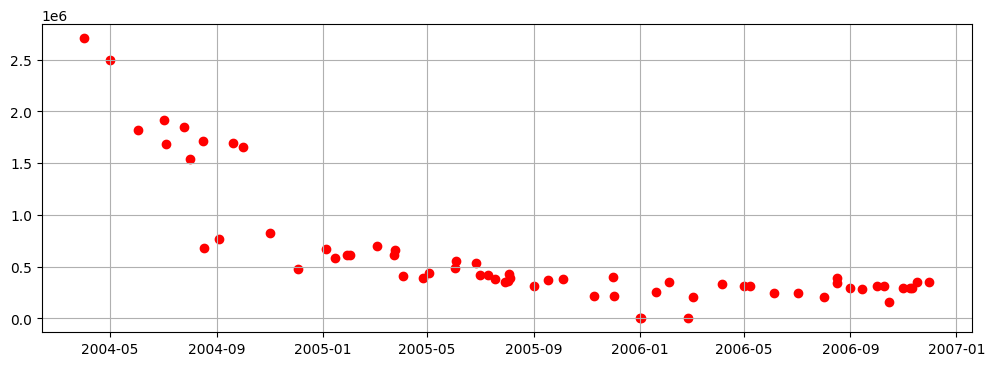

In [22]:
plt.figure(figsize=(12,4))
plt.scatter(y=dca_df['Rate (SCF/d)'],x=dca_df.index,marker='o', color='red')
plt.grid()

now from the theory of dca , we know that hyperbolic curve will be the best fit on this data

In [35]:
def q_hyp(t,qi,b,d):

  qfit=qi/(np.abs(1+b*d*t)**(1/b))

  return qfit

def hyp_fitter(q,t):
  # first we normalize the data so that it converges well and quick
  qn=q/max(q)
  tn=t/max(t)

  # curve fit (optimization of params)
  params= curve_fit(q_hyp,tn,qn)
  [qi,b,d]=params[0]

  # these are for normalized t and q
  # we must readjust for t and q(non-normalized)
  d_f=d/max(t)
  qi_f=qi*max(q)

  # now we can use these params
  q_hyp_fit=q_hyp(t,qi_f,b,d_f)

  return q_hyp_fit, params


In [36]:
q=dca_df['Rate (SCF/d)'] ; t=dca_df['days']
q_fit,params=hyp_fitter(q,t)

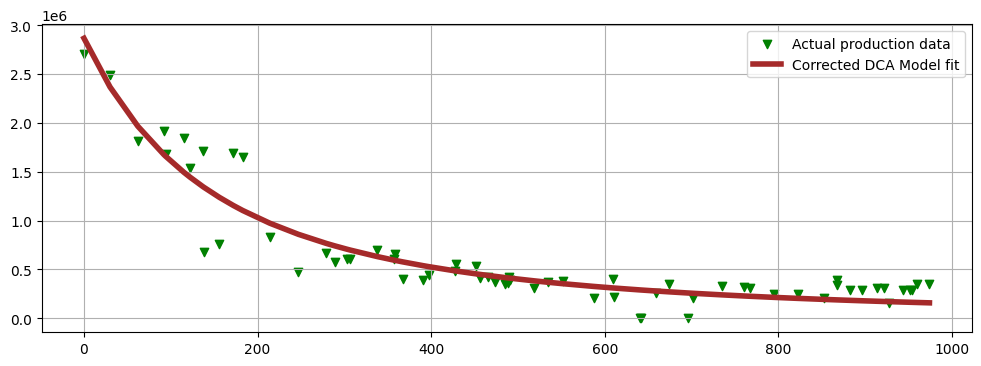

In [37]:
plt.figure(figsize=(12,4))
plt.scatter(t,q,marker='v',color='green',label='Actual production data')
plt.plot(t,q_fit,color='brown',lw=4, label='DCA Model fit')

##############################################
plt.grid()
plt.legend()

Note in this DCA technique(Physics base, Arps) we must know the eqn prior to project otherwise we can't do anything. Whereas in Data-driven approaches, we normally start with ONLY DATA and fit the model that suits the best.




# 2. EXPLORATORY DATA ANALYSIS ON VOLVE FIELD


In [41]:
df=pd.read_csv('https://raw.githubusercontent.com/Divyanshu-ISM/Machine-Learning-Deep-Learning/main/Volve%20P-12_DatesCorrected.csv',
               index_col=0, parse_dates=True)

In [43]:
df.head()

,onstreaminject_HRS,BORE_WI_VOL,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P in percentage,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
2007-01-09,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-01-10,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-01-11,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-01-12,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-01-13,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
df.head(10).columns


Index(['onstreaminject_HRS', 'BORE_WI_VOL', 'ON_STREAM_HRS',
       'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING',
       'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P in percentage', 'AVG_WHP_P',
       'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL',
       'BORE_WAT_VOL'],
      dtype='object')

<Axes: >

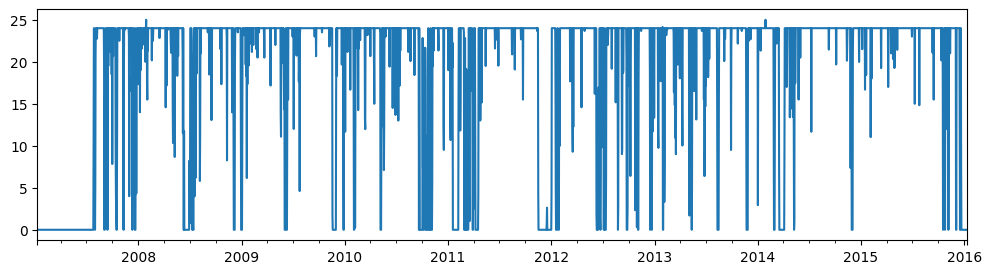

In [47]:
df['onstreaminject_HRS'].plot(figsize=(12,3))

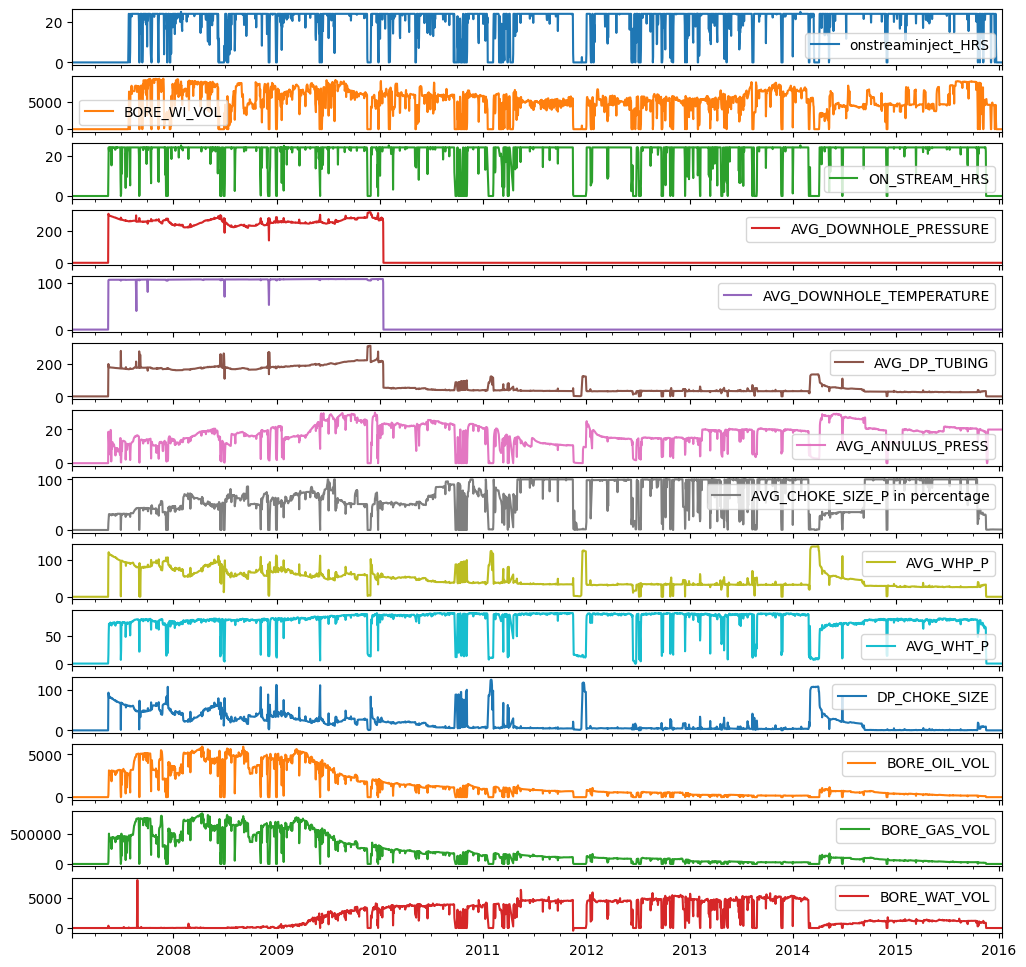

In [42]:
df.plot(subplots=True, figsize=(12,12));

In [49]:
df.corr()

,onstreaminject_HRS,BORE_WI_VOL,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P in percentage,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
onstreaminject_HRS,1.000000,0.841863,0.721919,-0.008906,0.012351,0.009337,0.612743,0.633598,-0.023190,0.672484,-0.263239,0.182405,0.187947,0.411186
BORE_WI_VOL,0.841863,1.000000,0.664087,0.200564,0.221163,0.200725,0.557878,0.521919,0.093025,0.603670,-0.121651,0.368739,0.374942,0.280289
ON_STREAM_HRS,0.721919,0.664087,1.000000,0.151285,0.165454,0.143750,0.664548,0.736508,0.145377,0.890115,-0.150569,0.361124,0.371698,0.441695
AVG_DOWNHOLE_PRESSURE,-0.008906,0.200564,0.151285,1.000000,0.995501,0.959016,0.043809,-0.236868,0.607089,0.067182,0.570080,0.819920,0.816354,-0.447753
AVG_DOWNHOLE_TEMPERATURE,0.012351,0.221163,0.165454,0.995501,1.000000,0.952678,0.050419,-0.220456,0.600172,0.077749,0.556476,0.850241,0.845233,-0.456028
AVG_DP_TUBING,0.009337,0.200725,0.143750,0.959016,0.952678,1.000000,0.085105,-0.247804,0.700270,0.081012,0.651796,0.778941,0.774962,-0.403919
AVG_ANNULUS_PRESS,0.612743,0.557878,0.664548,0.043809,0.050419,0.085105,1.000000,0.424520,0.023069,0.637504,-0.203826,0.163663,0.165688,0.299597
AVG_CHOKE_SIZE_P in percentage,0.633598,0.521919,0.736508,-0.236868,-0.220456,-0.247804,0.424520,1.000000,-0.259519,0.775045,-0.501936,-0.049757,-0.043856,0.676490
AVG_WHP_P,-0.023190,0.093025,0.145377,0.607089,0.600172,0.700270,0.023069,-0.259519,1.000000,0.103721,0.934167,0.544204,0.548123,-0.323962
AVG_WHT_P,0.672484,0.603670,0.890115,0.067182,0.077749,0.081012,0.637504,0.775045,0.103721,1.000000,-0.223074,0.245750,0.256457,0.580916


## Nulls
ML cant work on null data, there has to be something, if empty values are there try to fill it with the most relevant data in place. i.e the work of a datascientist.

<Axes: >

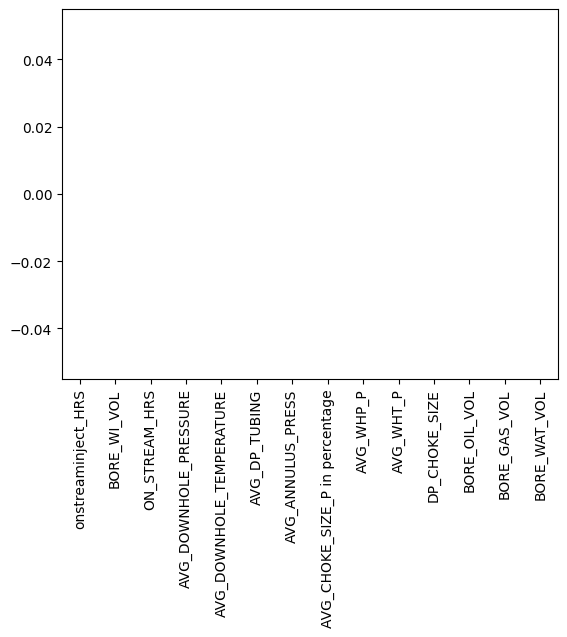

In [50]:
df.isnull().sum().sort_values().plot(kind='bar')

<Axes: >

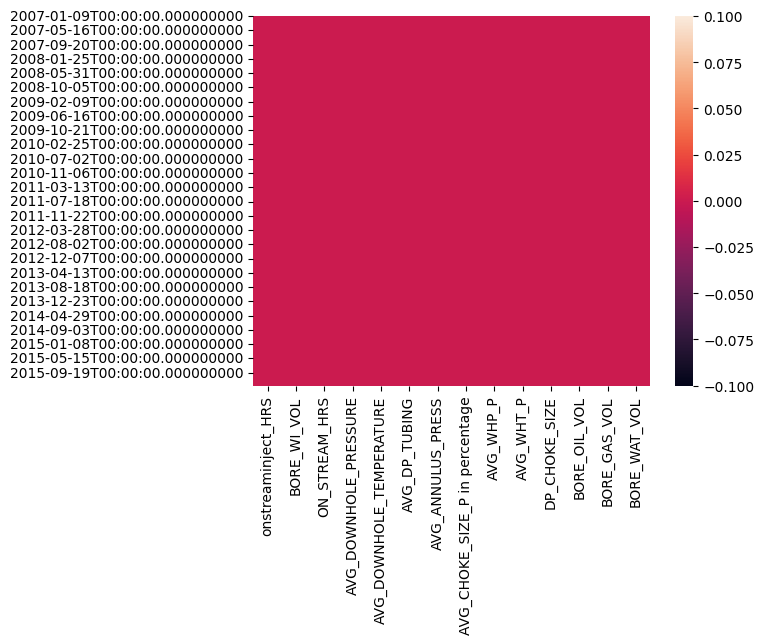

In [52]:
sns.heatmap(df.isnull())



> Descriptive statistics



try to analyze if and when outliers are there looking at max vs IQR

In [53]:
df.describe()

,onstreaminject_HRS,BORE_WI_VOL,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P in percentage,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
count,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000,3291.000000
mean,19.528256,4935.663628,20.017419,76.283155,31.424488,80.758924,16.368846,64.158081,45.803679,74.345872,18.657338,1402.086752,204365.771346,2105.660438
std,8.669803,2625.955533,8.303784,118.248271,48.547561,73.006429,7.197959,33.810811,25.954204,26.140866,22.896388,1642.492700,232710.410394,1952.495950
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-458.000000
25%,21.670000,3972.500000,24.000000,0.000000,0.000000,32.235500,12.543000,40.983840,32.199000,76.549000,3.663500,211.000000,33259.000000,40.500000
50%,24.000000,5335.000000,24.000000,0.000000,0.000000,37.921250,18.019000,65.988040,37.464000,81.693000,6.819000,664.000000,101142.000000,1260.000000
75%,24.000000,6851.500000,24.000000,235.838500,105.919000,170.045500,20.587000,99.895675,59.079500,90.002500,26.760500,2026.000000,295593.000000,4109.000000
max,25.000000,9316.000000,25.000000,317.701000,107.508000,314.409000,30.020000,100.000000,137.311000,92.459000,124.123000,5902.000000,851132.000000,8020.000000


Create a dunction that scales the dataset

In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#3. Machine Learning(Regression)


> Oil Production Prediction

Assumptions of Linear Regression

1. Features musn't be intercorrelated.
2. Linear Regression bw X and Y is expected.
3. Homoskedasticity: Errors must not be sensitive to any specific ranges of X.
4. Normally distributed features.



## 4. Machine Learning (Classification)